In [34]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [35]:
df = pd.read_csv("../data/raw/enron_spam_data.csv")

In [36]:
df.head(10)

,Unnamed: 0,Subject,Message,Spam/Ham,Date
0,0,christmas tree farm pictures,NaN,ham,1999-12-10
1,1,"vastar resources , inc .","gary , production from the high island larger ...",ham,1999-12-13
2,2,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,ham,1999-12-14
3,3,re : issue,fyi - see note below - already done .\nstella\...,ham,1999-12-14
4,4,meter 7268 nov allocation,fyi .\n- - - - - - - - - - - - - - - - - - - -...,ham,1999-12-14
5,5,mcmullen gas for 11 / 99,"jackie ,\nsince the inlet to 3 river plant is ...",ham,1999-12-14
6,6,meter 1517 - jan 1999,"george ,\ni need the following done :\njan 13\...",ham,1999-12-14
7,7,duns number changes,fyi\n- - - - - - - - - - - - - - - - - - - - -...,ham,1999-12-14
8,8,king ranch,there are two fields of gas that i am having d...,ham,1999-12-14
9,9,re : entex transistion,thanks so much for the memo . i would like to ...,ham,1999-12-14


In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 33716 entries, 0 to 33715
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  33716 non-null  int64
 1   Subject     33716 non-null  str  
 2   Message     33664 non-null  str  
 3   Spam/Ham    33716 non-null  str  
 4   Date        33716 non-null  str  
dtypes: int64(1), str(4)
memory usage: 1.3 MB


### Drop unnecessary column in dataset

In [38]:
df = df.drop(columns=['Unnamed: 0'])

In [39]:
df.head(10)

,Subject,Message,Spam/Ham,Date
0,christmas tree farm pictures,NaN,ham,1999-12-10
1,"vastar resources , inc .","gary , production from the high island larger ...",ham,1999-12-13
2,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,ham,1999-12-14
3,re : issue,fyi - see note below - already done .\nstella\...,ham,1999-12-14
4,meter 7268 nov allocation,fyi .\n- - - - - - - - - - - - - - - - - - - -...,ham,1999-12-14
5,mcmullen gas for 11 / 99,"jackie ,\nsince the inlet to 3 river plant is ...",ham,1999-12-14
6,meter 1517 - jan 1999,"george ,\ni need the following done :\njan 13\...",ham,1999-12-14
7,duns number changes,fyi\n- - - - - - - - - - - - - - - - - - - - -...,ham,1999-12-14
8,king ranch,there are two fields of gas that i am having d...,ham,1999-12-14
9,re : entex transistion,thanks so much for the memo . i would like to ...,ham,1999-12-14


In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 33716 entries, 0 to 33715
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Subject   33716 non-null  str  
 1   Message   33664 non-null  str  
 2   Spam/Ham  33716 non-null  str  
 3   Date      33716 non-null  str  
dtypes: str(4)
memory usage: 1.0 MB


calculate percentage of empty messages across the dataset

In [41]:
total = len(df)
missing = df["Message"].isna().sum()
ratio = missing/total
ratio*100

np.float64(0.1542294459603749)

Empty-body messages make up only â‰ˆ0.15% of the dataset, so dropping them has negligible impact on data volume or class balanceâ€”safe to remove for the main EDA/modeling pipeline.

In [42]:
empty_df = df[df['Message'].isna() | (df['Message'].str.strip() == '')]


In [43]:
empty_df.head()

,Subject,Message,Spam/Ham,Date
0,christmas tree farm pictures,NaN,ham,1999-12-10
183,day 26 - txu lonestar called on 20000 at carthage,NaN,ham,2000-01-25
199,is this fri feb 11 a problem for taking vacati...,NaN,ham,2000-01-28
304,http : / / www . pge - texas . com / www / gtt...,NaN,ham,2000-02-15
1655,revised,NaN,ham,2000-09-21


In [44]:
empty_df.to_csv('../data/raw/empty_messages.csv', index=False)

remove row with empty message in dataframe

In [45]:
df_clean = df.drop(empty_df.index).copy() 

In [46]:
df_clean.head()

,Subject,Message,Spam/Ham,Date
1,"vastar resources , inc .","gary , production from the high island larger ...",ham,1999-12-13
2,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,ham,1999-12-14
3,re : issue,fyi - see note below - already done .\nstella\...,ham,1999-12-14
4,meter 7268 nov allocation,fyi .\n- - - - - - - - - - - - - - - - - - - -...,ham,1999-12-14
5,mcmullen gas for 11 / 99,"jackie ,\nsince the inlet to 3 river plant is ...",ham,1999-12-14


In [47]:
df_clean.shape

(33664, 4)

In [48]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 33664 entries, 1 to 33715
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Subject   33664 non-null  str  
 1   Message   33664 non-null  str  
 2   Spam/Ham  33664 non-null  str  
 3   Date      33664 non-null  str  
dtypes: str(4)
memory usage: 1.3 MB


mapping label

In [49]:
label_map = {'ham': 0, 'spam': 1}
df_clean['label'] = df_clean['Spam/Ham'].str.strip().str.lower().map(label_map)


In [50]:
df_clean.head()

,Subject,Message,Spam/Ham,Date,label
1,"vastar resources , inc .","gary , production from the high island larger ...",ham,1999-12-13,0
2,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,ham,1999-12-14,0
3,re : issue,fyi - see note below - already done .\nstella\...,ham,1999-12-14,0
4,meter 7268 nov allocation,fyi .\n- - - - - - - - - - - - - - - - - - - -...,ham,1999-12-14,0
5,mcmullen gas for 11 / 99,"jackie ,\nsince the inlet to 3 river plant is ...",ham,1999-12-14,0


In [51]:
label_counts = df_clean['label'].value_counts(normalize=True)
spam_ratio = label_counts.get(1, 0.0)
ham_ratio = label_counts.get(0, 0.0)
print(spam_ratio)
print(ham_ratio)

0.5100701045627376
0.48992989543726234


- Spam makes up 51% vs 49% ham so the classes are fairly balanced

### Length feature

In [52]:
df_clean['message_len'] = df_clean['Message'].str.len()
df_clean['subject_len'] = df_clean['Subject'].str.len()

In [53]:
df_clean.head(10)

,Subject,Message,Spam/Ham,Date,label,message_len,subject_len
1,"vastar resources , inc .","gary , production from the high island larger ...",ham,1999-12-13,0,4282,24
2,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,ham,1999-12-14,0,38,28
3,re : issue,fyi - see note below - already done .\nstella\...,ham,1999-12-14,0,1171,10
4,meter 7268 nov allocation,fyi .\n- - - - - - - - - - - - - - - - - - - -...,ham,1999-12-14,0,1124,25
5,mcmullen gas for 11 / 99,"jackie ,\nsince the inlet to 3 river plant is ...",ham,1999-12-14,0,534,24
6,meter 1517 - jan 1999,"george ,\ni need the following done :\njan 13\...",ham,1999-12-14,0,411,21
7,duns number changes,fyi\n- - - - - - - - - - - - - - - - - - - - -...,ham,1999-12-14,0,1375,19
8,king ranch,there are two fields of gas that i am having d...,ham,1999-12-14,0,1616,10
9,re : entex transistion,thanks so much for the memo . i would like to ...,ham,1999-12-14,0,3039,22
10,entex transistion,the purpose of the email is to recap the kicko...,ham,1999-12-14,0,1734,17


In [54]:
length_stats = df_clean.groupby('label')[['message_len', 'subject_len']].describe()
length_stats

message_len                                                          \
            count         mean          std    min    25%     50%     75%   
label                                                                       
0         16493.0  1681.574304  5782.971447    1.0  311.0   771.0  1670.0   
1         17171.0  1582.563858  1622.216122  632.0  632.0  1180.0  1674.0   

                subject_len                                                \
            max       count       mean        std   min   25%   50%   75%   
label                                                                       
0      228353.0     16493.0  30.964591  25.533661   1.0  18.0  27.0  41.0   
1        6600.0     17171.0  28.565255  12.767874  13.0  18.0  25.0  47.0   

               
          max  
label          
0      1355.0  
1        47.0

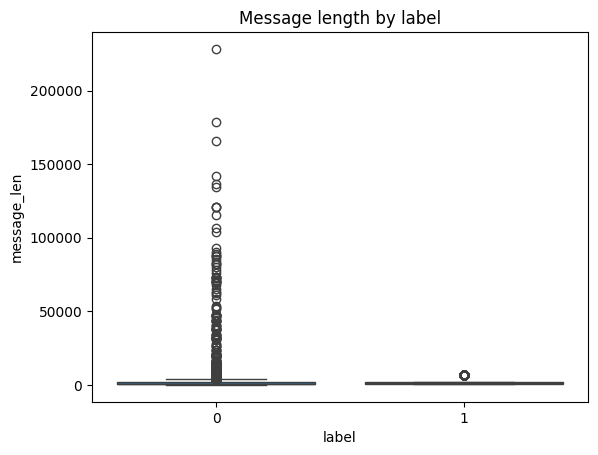

In [55]:
sns.boxplot(data=df_clean, x='label', y='message_len')
plt.title('Message length by label')
plt.show()

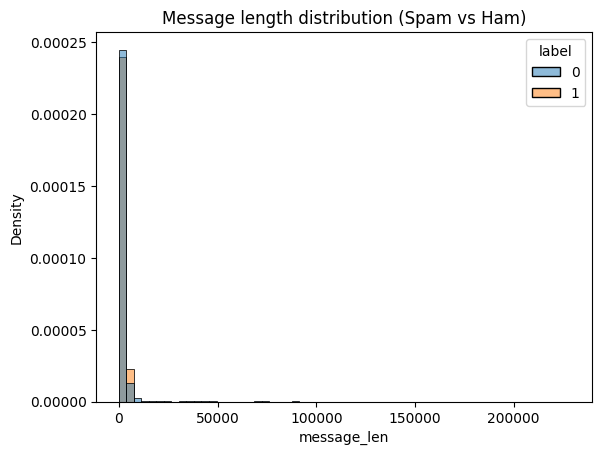

In [56]:
sns.histplot(data=df_clean, x='message_len', hue='label', bins=60, kde=False, stat='density',                
  common_norm=False)                                                                                           
plt.title('Message length distribution (Spam vs Ham)')                                                       
plt.show()   

In [57]:
df_clean['Date'] = pd.to_datetime(df_clean['Date'], errors='coerce')                                         
missing_dates = df_clean['Date'].isna().sum()     
print(f"Invalid/missing dates: {missing_dates}")  

Invalid/missing dates: 0


In [58]:
daily_counts = df_clean.groupby(df_clean['Date'].dt.date)['label'].agg(['count', 'mean'])                    
daily_counts.rename(columns={'count': 'total', 'mean': 'spam_ratio'}, inplace=True)   
daily_counts

,total,spam_ratio
Date,,
1999-12-10,3,0.0
1999-12-12,1,0.0
1999-12-13,4,0.0
1999-12-14,17,0.0
1999-12-15,11,0.0
...,...,...
2005-09-02,6,1.0
2005-09-03,5,1.0
2005-09-04,5,1.0


In [59]:
weekday_counts = df_clean.groupby(df_clean['Date'].dt.weekday)['label'].agg(['count', 'mean'])
weekday_counts.rename(columns={'count': 'total', 'mean': 'spam_ratio'}, inplace=True)
weekday_map = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
weekday_counts.index = weekday_counts.index.map(weekday_map.get)
weekday_counts = weekday_counts.reindex(list(weekday_map.values()))
weekday_counts


,total,spam_ratio
Date,,
Mon,5489,0.428493
Tue,6150,0.472195
Wed,5934,0.448264
Thu,5667,0.444327
Fri,5408,0.446746
Sat,2425,0.876701
Sun,2591,0.847163


In [60]:
print(daily_counts.head())                                                                                   
print(weekday_counts)                                                                                        

            total  spam_ratio
Date                         
1999-12-10      3         0.0
1999-12-12      1         0.0
1999-12-13      4         0.0
1999-12-14     17         0.0
1999-12-15     11         0.0
      total  spam_ratio
Date                   
Mon    5489    0.428493
Tue    6150    0.472195
Wed    5934    0.448264
Thu    5667    0.444327
Fri    5408    0.446746
Sat    2425    0.876701
Sun    2591    0.847163


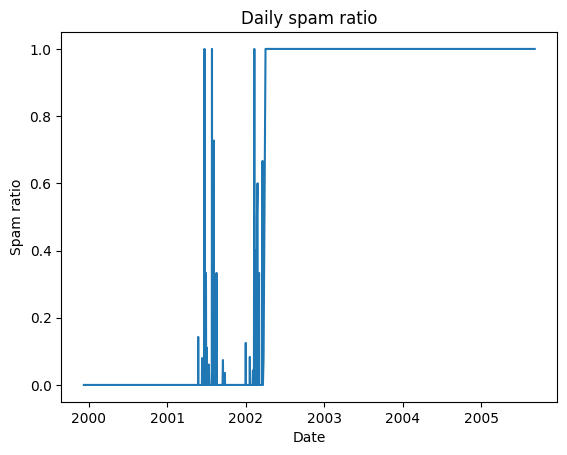

In [61]:
daily_counts['spam_ratio'].plot(kind='line', title='Daily spam ratio')                                       
plt.ylabel('Spam ratio')                                                                                     
plt.show()    

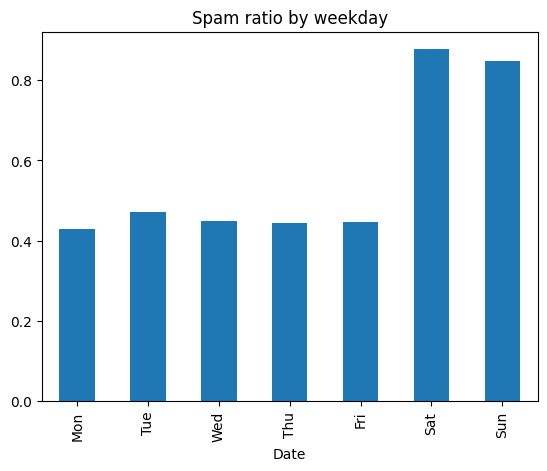

In [62]:
weekday_counts['spam_ratio'].plot(kind='bar', title='Spam ratio by weekday')                                 
plt.show()     

In [63]:
from pathlib import Path

out_dir = Path("../data/processed")
out_dir.mkdir(parents=True, exist_ok=True) 


In [64]:
df_clean.to_csv(out_dir / "eda_df_clean.csv", index=False)  
length_stats.to_csv(out_dir / "eda_length_stats.csv")                                                                                               
daily_counts.to_csv(out_dir / "eda_daily_counts.csv")                                                                                               
weekday_counts.to_csv(out_dir / "eda_weekday_count.csv")